# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

In [3]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# shorter history

## Fit multiple

In [112]:
# Fit
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
self_coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}
ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        if i == j:
            model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **self_coupling_filter_params)
            continue
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        if i == j:
            model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **self_coupling_filter_params)
            continue
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('refractory', target_probe, order=order, tau=tau,apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1

6it [03:39, 36.64s/it]


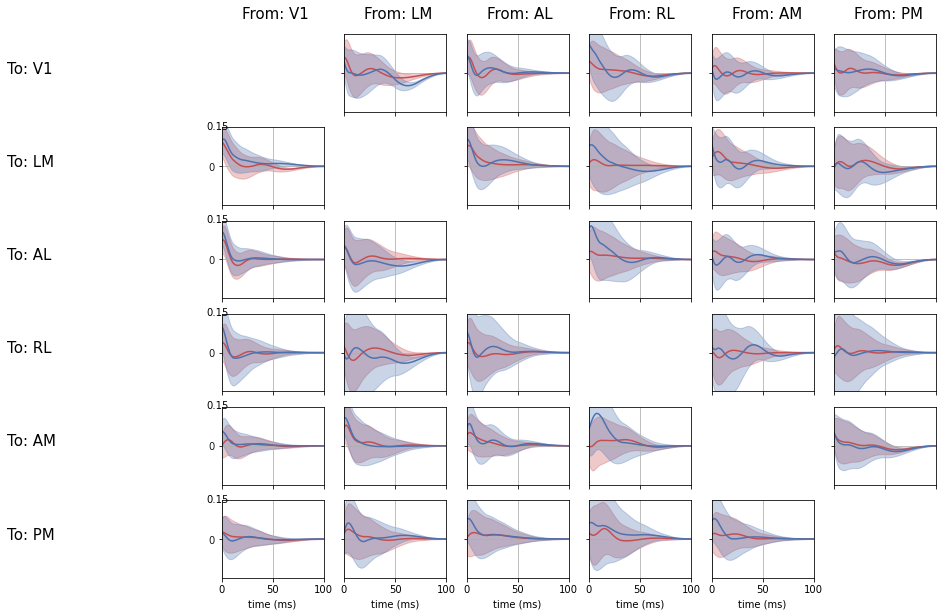

In [113]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=False, 
                              plot_self=False)

In [114]:
MAX_FIRING_RATE = 3.5
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = running_model_list
spikes_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
log_firing_rate_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
explosion_trial = 0

import copy
import numpy.random

for itrial in range(model_list[0].ntrial):
#     while True:
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories
                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = spikes[0, :, 0]

        for t in range(1, nt):
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            log_firing_rate[t,:,0] += temp_log_firing_rate
            log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        if np.any(log_firing_rate==MAX_FIRING_RATE):
            explosion_trial += 1
            break
        else:
            spikes_rcd[:,:,itrial] = spikes
            log_firing_rate_rcd[:,:,itrial] = log_firing_rate
            break
            
print("running")
print(f"explosion trial percentage: {explosion_trial/model_list[0].ntrial}")

MAX_FIRING_RATE = 3.5
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = stationary_model_list
spikes_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
log_firing_rate_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
explosion_trial = 0

import copy
import numpy.random

for itrial in range(model_list[0].ntrial):
    while True:
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories
                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = spikes[0, :, 0]

        for t in range(1, nt):
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            log_firing_rate[t,:,0] += temp_log_firing_rate
            log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        if np.any(log_firing_rate==MAX_FIRING_RATE):
            explosion_trial += 1
            break
        else:
            spikes_rcd[:,:,itrial] = spikes
            log_firing_rate_rcd[:,:,itrial] = log_firing_rate
            break

print("stationary")
print(f"explosion trial percentage: {explosion_trial/model_list[0].ntrial}")
total_nll = sum([running_model_list[i].aic for i in range(6)]) + sum([stationary_model_list[i].aic for i in range(6)])

print(f"likelihood: {total_nll}")


running
explosion trial percentage: 0.0
stationary
explosion trial percentage: 0.6356589147286822
likelihood: 285605.4676659989


@ coupling, history

@ 20, 20
running
explosion trial percentage: 0.48148148148148145
stationary
explosion trial percentage: 1.3565891472868217
likelihood: 286259.99453823874

@ 50, 50
running
explosion trial percentage: 0.48148148148148145
stationary
explosion trial percentage: 1.3565891472868217
likelihood: 286259.99453823874

In [119]:
# Satured model
total_nll = 0
for i in range(6):
    model = running_model_list[i]
    total_nll += GLM.spike_trains_neg_log_likelihood(np.log(model.output+1e-5), model.output, max_spike=None)
    model = stationary_model_list[i]
    total_nll += GLM.spike_trains_neg_log_likelihood(np.log(model.output+1e-5), model.output, max_spike=None)
print(f"Satured likelihood: {total_nll}")


Satured likelihood: 98594.95795080707


# Only trial-wise inhomogeneous baseline

In [207]:
penalty = 3e-2
tau = 10
order = 2
num_basis_baseline = 10
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('trialwise_inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=False, **coupling_filter_params)
#     model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('trial_coef')
    model.fit(target_probe, verbose=False, penalty=penalty)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    running_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_output[i,j] = filter_list[k]
        k += 1
    
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('trialwise_inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=False, **coupling_filter_params)
#     model.add_effect('refractory', target_probe, order=order, tau=tau,apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('trial_coef')
    model.fit(target_probe, verbose=False, penalty=penalty)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    stationary_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_output[i,j] = filter_list[k]
        k += 1

0it [00:07, ?it/s]


IndexError: list index out of range

In [ ]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=False, 
                              plot_self=False)

In [103]:
MAX_FIRING_RATE = 3.5
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = running_model_list
spikes_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
log_firing_rate_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
explosion_trial = 0

import copy
import numpy.random

for itrial in range(model_list[0].ntrial):
#     while True:
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['trialwise_inhomogeneous_baseline', 'coupling', 'trial_coef']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['trialwise_inhomogeneous_baseline']:
                    start = itrial*num_basis_baseline
                    end = (itrial+1)*num_basis_baseline
                    baseline_mat[:, ineuron] = (model.basis_list[ieffect][:,start:end]@ \
                        model.results.params[start:end][:,np.newaxis]).squeeze()
                    
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories
                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = spikes[0, :, 0]

        for t in range(1, nt):
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            log_firing_rate[t,:,0] += temp_log_firing_rate
            log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        if np.any(log_firing_rate==MAX_FIRING_RATE):
            explosion_trial += 1
            break
        else:
            spikes_rcd[:,:,itrial] = spikes
            log_firing_rate_rcd[:,:,itrial] = log_firing_rate
            break
            
print("running")
print(f"explosion trial percentage: {explosion_trial/model_list[0].ntrial}")

MAX_FIRING_RATE = 3.5
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = stationary_model_list
spikes_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
log_firing_rate_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
explosion_trial = 0

import copy
import numpy.random

for itrial in range(model_list[0].ntrial):
    while True:
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['trialwise_inhomogeneous_baseline', 'coupling', 'trial_coef']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['trialwise_inhomogeneous_baseline']:
                    start = itrial*num_basis_baseline
                    end = (itrial+1)*num_basis_baseline
                    baseline_mat[:, ineuron] = (model.basis_list[ieffect][:,start:end]@ \
                        model.results.params[start:end][:,np.newaxis]).squeeze()

                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories
                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = spikes[0, :, 0]

        for t in range(1, nt):
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            log_firing_rate[t,:,0] += temp_log_firing_rate
            log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        if np.any(log_firing_rate==MAX_FIRING_RATE):
            explosion_trial += 1
            break
        else:
            spikes_rcd[:,:,itrial] = spikes
            log_firing_rate_rcd[:,:,itrial] = log_firing_rate
            break

print("stationary")
print(f"explosion trial percentage: {explosion_trial/model_list[0].ntrial}")
total_nll = sum([running_model_list[i].aic for i in range(6)]) + sum([stationary_model_list[i].aic for i in range(6)])

print(f"likelihood: {total_nll}")


running
explosion trial percentage: 0.012345679012345678


ValueError: lam value too large

In [120]:
total_nll = sum([running_model_list[i].aic for i in range(6)]) + sum([stationary_model_list[i].aic for i in range(6)])

print(f"likelihood: {total_nll}")

likelihood: 285605.4676659989


@ 15 inhomo basis; no penalty
267310.4862220675



# Time-warping template + trial-wise inhomo

In [216]:
# Fit
penalty = 30e-1
tau = 10
order = 2
num_basis_baseline = 30
num_basis_baseline_trialwise = 10
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
self_coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}
ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    model.add_effect('trialwise_inhomogeneous_baseline', num=num_basis_baseline_trialwise, apply_no_penalty=False)
    for j, input_probe in enumerate(probe_list):
        if i == j:
            model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **self_coupling_filter_params)
            continue
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    model.add_effect('trialwise_inhomogeneous_baseline', num=num_basis_baseline_trialwise, apply_no_penalty=False)
    for j, input_probe in enumerate(probe_list):
        if i == j:
            model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **self_coupling_filter_params)
            continue
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau,apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1

3it [07:37, 152.37s/it]


LinAlgError: SVD did not converge

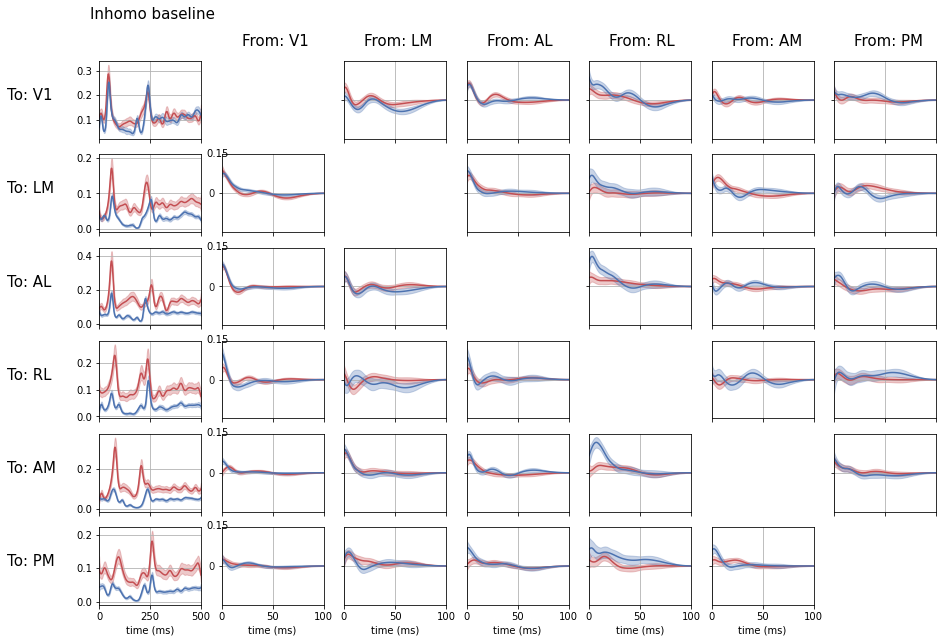

In [214]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=True, 
                              plot_self=False)

In [141]:
MAX_FIRING_RATE = 3.5
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = running_model_list
spikes_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
log_firing_rate_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
explosion_trial = 0

import copy
import numpy.random

for itrial in range(model_list[0].ntrial):
#     while True:
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['trialwise_inhomogeneous_baseline','inhomogeneous_baseline', 'coupling', 'trial_coef']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):
                if effect_type=='trialwise_inhomogeneous_baseline':
                    continue
                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect-1])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories
                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect-1])

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = spikes[0, :, 0]

        for t in range(1, nt):
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            log_firing_rate[t,:,0] += temp_log_firing_rate
            log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        if np.any(log_firing_rate==MAX_FIRING_RATE):
            explosion_trial += 1
            break
        else:
            spikes_rcd[:,:,itrial] = spikes
            log_firing_rate_rcd[:,:,itrial] = log_firing_rate
            break
            
print("running")
print(f"explosion trial percentage: {explosion_trial/model_list[0].ntrial}")

MAX_FIRING_RATE = 3.5
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = stationary_model_list
spikes_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
log_firing_rate_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
explosion_trial = 0

import copy
import numpy.random

for itrial in range(model_list[0].ntrial):
    while True:
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['trialwise_inhomogeneous_baseline','inhomogeneous_baseline', 'coupling', 'trial_coef']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):
                if effect_type=='trialwise_inhomogeneous_baseline':
                    continue
                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect-1])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories
                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect-1])

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = spikes[0, :, 0]

        for t in range(1, nt):
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            log_firing_rate[t,:,0] += temp_log_firing_rate
            log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        if np.any(log_firing_rate==MAX_FIRING_RATE):
            explosion_trial += 1
            break
        else:
            spikes_rcd[:,:,itrial] = spikes
            log_firing_rate_rcd[:,:,itrial] = log_firing_rate
            break

print("stationary")
print(f"explosion trial percentage: {explosion_trial/model_list[0].ntrial}")



running
explosion trial percentage: 0.0
stationary
explosion trial percentage: 0.0
likelihood: 278791.80151342845


In [213]:
total_nll = sum([running_model_list[i].aic for i in range(6)]) + sum([stationary_model_list[i].aic for i in range(6)])

print(f"likelihood: {total_nll}")

likelihood: 292773.15633798274


@ 10 extra inhomo basis
running
explosion trial percentage: 0.0
stationary
explosion trial percentage: 0.0
likelihood: 278791.80151342845



# Time-warping template + inhomo

In [ ]:
# Fit
penalty = 1e-1
tau = 10
order = 2
num_basis_baseline = 30
num_basis_baseline_trialwise = 10
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
self_coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}
ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline_trialwise, extend_zeros=150, apply_no_penalty=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 2
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline_trialwise, extend_zeros=150, apply_no_penalty=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau,apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 2
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1

3it [01:50, 36.84s/it]

In [270]:
model.basis_name

['time_warping_inhomogeneous_baseline',
 'inhomogeneous_baseline',
 'coupling from AM',
 'coupling from PM',
 'coupling from V1',
 'coupling from LM',
 'coupling from AL',
 'coupling from RL',
 'refractory',
 'trial_coef']

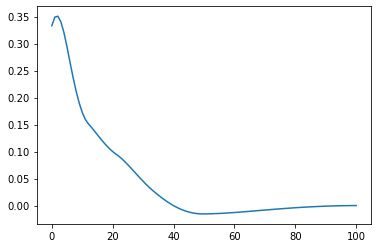

In [271]:
plt.plot(filter_list[7][0])

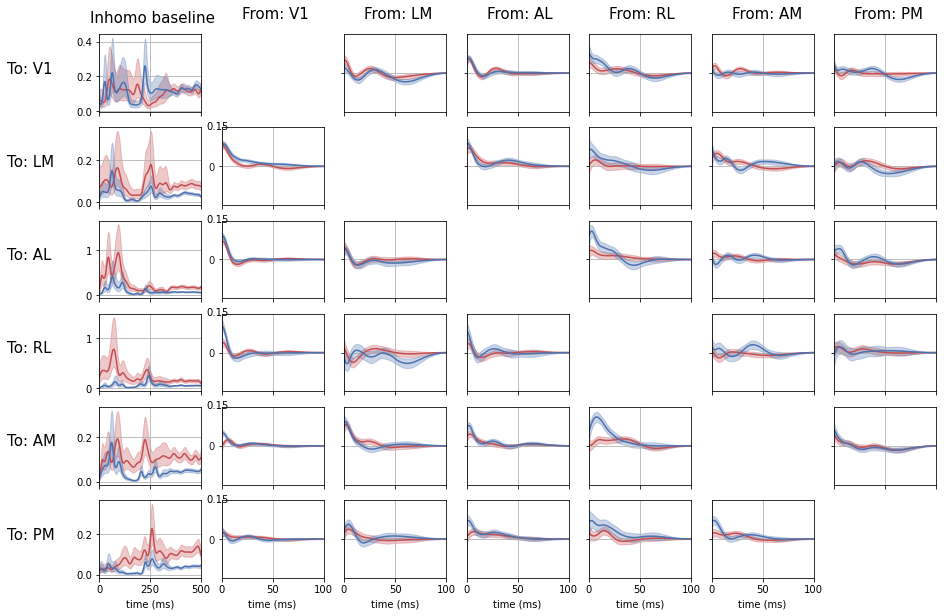

In [272]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=True, 
                              plot_self=False)

In [141]:
MAX_FIRING_RATE = 3.5
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = running_model_list
spikes_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
log_firing_rate_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
explosion_trial = 0

import copy
import numpy.random

for itrial in range(model_list[0].ntrial):
#     while True:
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['trialwise_inhomogeneous_baseline','inhomogeneous_baseline', 'coupling', 'trial_coef']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):
                if effect_type=='trialwise_inhomogeneous_baseline':
                    continue
                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect-1])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories
                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect-1])

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = spikes[0, :, 0]

        for t in range(1, nt):
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            log_firing_rate[t,:,0] += temp_log_firing_rate
            log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        if np.any(log_firing_rate==MAX_FIRING_RATE):
            explosion_trial += 1
            break
        else:
            spikes_rcd[:,:,itrial] = spikes
            log_firing_rate_rcd[:,:,itrial] = log_firing_rate
            break
            
print("running")
print(f"explosion trial percentage: {explosion_trial/model_list[0].ntrial}")

MAX_FIRING_RATE = 3.5
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = stationary_model_list
spikes_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
log_firing_rate_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
explosion_trial = 0

import copy
import numpy.random

for itrial in range(model_list[0].ntrial):
    while True:
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['trialwise_inhomogeneous_baseline','inhomogeneous_baseline', 'coupling', 'trial_coef']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):
                if effect_type=='trialwise_inhomogeneous_baseline':
                    continue
                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect-1])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories
                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect-1])

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = spikes[0, :, 0]

        for t in range(1, nt):
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            log_firing_rate[t,:,0] += temp_log_firing_rate
            log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        if np.any(log_firing_rate==MAX_FIRING_RATE):
            explosion_trial += 1
            break
        else:
            spikes_rcd[:,:,itrial] = spikes
            log_firing_rate_rcd[:,:,itrial] = log_firing_rate
            break

print("stationary")
print(f"explosion trial percentage: {explosion_trial/model_list[0].ntrial}")



running
explosion trial percentage: 0.0
stationary
explosion trial percentage: 0.0
likelihood: 278791.80151342845


In [273]:
total_nll = sum([running_model_list[i].aic for i in range(6)]) + sum([stationary_model_list[i].aic for i in range(6)])

print(f"likelihood: {total_nll}")

likelihood: 283384.1759048725


# Check CI of beta

## output of my model

In [150]:
max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model_stationary.add_effect('trial_coef')
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.fit(target_probe, verbose=True)


print(model_stationary.results.params)
print(model_stationary.results.bse)
model_mine = model_stationary

Negative log likelihood is: 32186.05
aic/2 is: 32252.05
[-2.13717184e+00 -1.11050575e+00 -1.90611070e+00 -6.85291747e-01
 -9.75049553e-01 -1.30783869e+00 -1.93740916e+00 -2.04642519e+00
 -1.93469837e+00 -1.99921363e+00 -2.24394008e+00 -1.69098158e+00
 -1.19830959e+00 -1.10118995e+00 -1.09154995e+00 -1.30809544e+00
 -1.38851902e+00 -1.45095366e+00 -1.31197618e+00 -1.45655401e+00
 -1.46248596e+00 -1.35856778e+00 -1.55411934e+00 -1.15122576e+00
 -1.27373887e+00 -1.26484164e+00 -1.29243616e+00 -1.37317963e+00
 -1.30903945e+00 -1.64147565e+00  6.52890508e-02 -9.77737689e-02
  7.45170677e-02 -5.70818283e-02  4.26873354e-02 -1.36903329e-02
  3.61256471e-02 -5.74704184e-03  2.66958151e-02 -1.56493919e-02
  2.37276863e-02 -8.91456450e-03  5.23926675e-02  1.11870050e-01
 -5.73048235e-02  2.55185232e-02  6.41521254e-03 -1.24239121e-02
  7.81449892e-02 -7.22546220e-02  6.74884018e-02 -8.39244377e-02
  7.99672618e-02 -6.69212880e-02  6.22513233e-02 -2.57455012e-02
 -2.36176883e-02  4.00420208e-02 -

## Output of SM

In [190]:
max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model_stationary.add_effect('trial_coef')
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.fit(target_probe, verbose=True, method='sm')

print(model_stationary.results.params)
print(model_stationary.results.bse)
model_sm = model_stationary

Negative log likelihood is: 32186.05
aic/2 is: 32252.05
[-2.13717184e+00 -1.11050575e+00 -1.90611070e+00 -6.85291747e-01
 -9.75049553e-01 -1.30783869e+00 -1.93740916e+00 -2.04642519e+00
 -1.93469837e+00 -1.99921363e+00 -2.24394008e+00 -1.69098158e+00
 -1.19830959e+00 -1.10118995e+00 -1.09154995e+00 -1.30809544e+00
 -1.38851902e+00 -1.45095366e+00 -1.31197618e+00 -1.45655401e+00
 -1.46248596e+00 -1.35856778e+00 -1.55411934e+00 -1.15122576e+00
 -1.27373887e+00 -1.26484164e+00 -1.29243616e+00 -1.37317963e+00
 -1.30903945e+00 -1.64147565e+00  6.52890508e-02 -9.77737689e-02
  7.45170677e-02 -5.70818283e-02  4.26873354e-02 -1.36903329e-02
  3.61256471e-02 -5.74704184e-03  2.66958151e-02 -1.56493919e-02
  2.37276863e-02 -8.91456450e-03  5.23926675e-02  1.11870050e-01
 -5.73048235e-02  2.55185232e-02  6.41521254e-03 -1.24239121e-02
  7.81449892e-02 -7.22546220e-02  6.74884018e-02 -8.39244377e-02
  7.99672618e-02 -6.69212880e-02  6.22513233e-02 -2.57455012e-02
 -2.36176883e-02  4.00420208e-02 -

In [154]:
model_stationary.response.shape

(64500,)

In [155]:
model_stationary.predictors.shape

(64500, 66)

## Output of R

In [156]:
# Dump to .csv file
np.savetxt("y.csv", model_stationary.response, delimiter=",")
np.savetxt("x.csv", model_stationary.predictors, delimiter=",")

R is also the same as my solver and SM. The standard error is indeed the uncertainty of the coefficients. 

## Bootstrap

In [191]:
nboot = 100

from random import choices
coefs = np.zeros((model_stationary.predictors.shape[1], nboot))
stationary_trials = [itrial for itrial in range(len(V1.stationary_trial_index)) if V1.stationary_trial_index[itrial] ]
for iboot in tqdm( range(nboot) ):
    # Create bootstrap index
    select_trials = np.array( choices(stationary_trials, k=len(stationary_trials)) )
    # Fit a model
    probe_list = V1.selected_probes
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
    # model.add_effect('trial_coef')
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    # model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model.fit(target_probe, verbose=False, method='mine')
    coefs[:, iboot] = model.results.params
    

100%|██████████████████████████████████| 100/100 [02:30<00:00,  1.50s/it]


In [193]:
np.std(coefs, axis=1)

array([0.14742206, 0.08402505, 0.09476294, 0.05847612, 0.06954961,
       0.06847343, 0.13058383, 0.11871599, 0.24983247, 0.16529398,
       0.19822268, 0.15125672, 0.07032231, 0.06882133, 0.0629977 ,
       0.07468161, 0.06402208, 0.0904963 , 0.12658737, 0.09984725,
       0.12006105, 0.09820372, 0.106687  , 0.06999429, 0.06704608,
       0.07595587, 0.08412145, 0.09550795, 0.09568246, 0.13152057,
       0.01805969, 0.02085405, 0.01997724, 0.01868399, 0.01506244,
       0.00828514, 0.02477915, 0.03101072, 0.02907236, 0.02409319,
       0.01942359, 0.01170476, 0.01476866, 0.01835177, 0.01444124,
       0.01042388, 0.00829123, 0.00524907, 0.02062849, 0.0268058 ,
       0.02963292, 0.02532425, 0.01940459, 0.01474239, 0.02350917,
       0.02884114, 0.02612058, 0.01987858, 0.01321535, 0.00713821,
       0.02727888, 0.03517157, 0.03600064, 0.03170052, 0.02235385,
       0.01360299])

## Correction for filters

In [208]:
# Fit
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
self_coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}
ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        if i == j:
            model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **self_coupling_filter_params)
            continue
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        if i == j:
            model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **self_coupling_filter_params)
            continue
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau,apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1

6it [03:38, 36.35s/it]


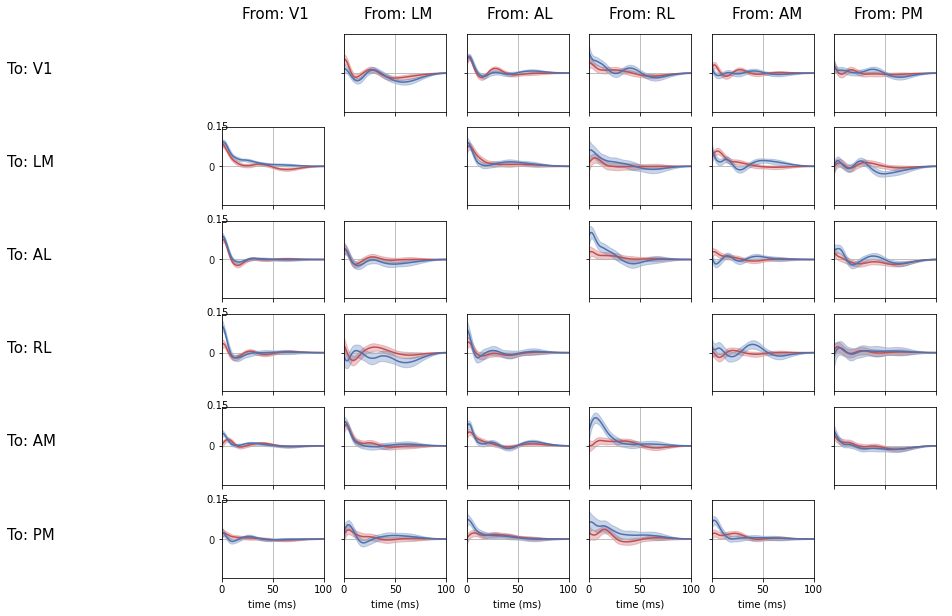

In [209]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=False, 
                              plot_self=False)